# Quickstart: Search over Tokens (SoT)

A framework for **test-time search** in autoregressive image generation. Instead of accepting the first AR sample, SoT explores multiple candidate token sequences, scores them with a verifier, and keeps the best to trade compute for quality.

This notebook covers:
1. Load a FlexTok AR model and an ImageReward verifier
2. Visualize the coarse-to-fine generation process
3. Run Best-of-N, Beam Search, and Lookahead Search
4. Compare FlexTok vs GridTok — why token order matters for search

In [1]:
import warnings
import logging
import io
import contextlib
import textwrap

# Suppress warnings/logs before importing third-party packages
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("l3m").setLevel(logging.ERROR)    # suppress MoE import message

import torch
import transformers
transformers.utils.logging.set_verbosity_error()
logging.getLogger("soto").setLevel(logging.INFO)     # keep soto model loading / search progress

# Wrap soto imports to suppress print() noise from third-party packages (e.g. janus)
with contextlib.redirect_stdout(io.StringIO()):
    from soto.ar_priors.base import ARPriorFactory
    from soto.verifiers.base import VerifierFactory
    from soto.search_algorithms.base import SearchAlgorithmFactory
    from soto.utils.viz import show_images, show_rows

FIXED_SEED = 0
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Setup

### 1.1 AR Prior
`ARPriorFactory.create` reads hyperparameters from the SoT YAML config, downloads weights from HuggingFace (cached after first run), and wraps the model in the SoT search interface. We start with **FlexAR-3B** — a 3.06B-parameter AR model generating images as 1D coarse-to-fine token sequences.

In [2]:
flextok_prior = ARPriorFactory.create("flextok_ar_3b", device=device)
print("FlexTok AR 3B loaded!")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 91.98it/s]


FlexTok AR 3B loaded!


### 1.2 Verifier

`VerifierFactory.create` loads a verifier that scores candidate images to guide search. We use **[ImageReward](https://github.com/zai-org/ImageReward)** for this notebook, a reward model trained on human preference data that captures text-image alignment.

In [3]:
verifier = VerifierFactory.create("image_reward", device=device)
print("ImageReward verifier loaded!")

ImageReward verifier loaded!


## 2. Visualizing the Generation Process

FlexTok generates images as a sequence of up to 256 tokens in **coarse-to-fine order**: the first token captures global semantics; subsequent tokens progressively add detail. Any prefix can be decoded into a complete (though coarser) image.

We generate all 256 tokens and decode at increasing prefix lengths to see this structure — and understand why it makes search effective. This is also the **direct AR baseline** for comparison with search.

In [4]:
PROMPT = "A painting of a red house with exactly three windows,\
a tall pine tree on one side and a large leafy tree on the other,\
under a bright blue sky with fluffy white clouds."

# Try your own prompts — compositionally complex descriptions (multiple objects, colors,
# spatial relations) tend to show the largest improvement from search.
# "A painting of a white plate on a table with a piece of bread on it, and a rose placed next to the plate."
# "Two flamingos in a colorful meadow, bright spring light, painterly realism"

print(f'Prompt: "{PROMPT}"')

Prompt: "A painting of a red house with exactly three windows,a tall pine tree on one side and a large leafy tree on the other,under a bright blue sky with fluffy white clouds."


FlexTok tokens: torch.Size([1, 256])  first 8: [34707, 21380, 1354, 36792, 41921, 58602, 38966, 63470]


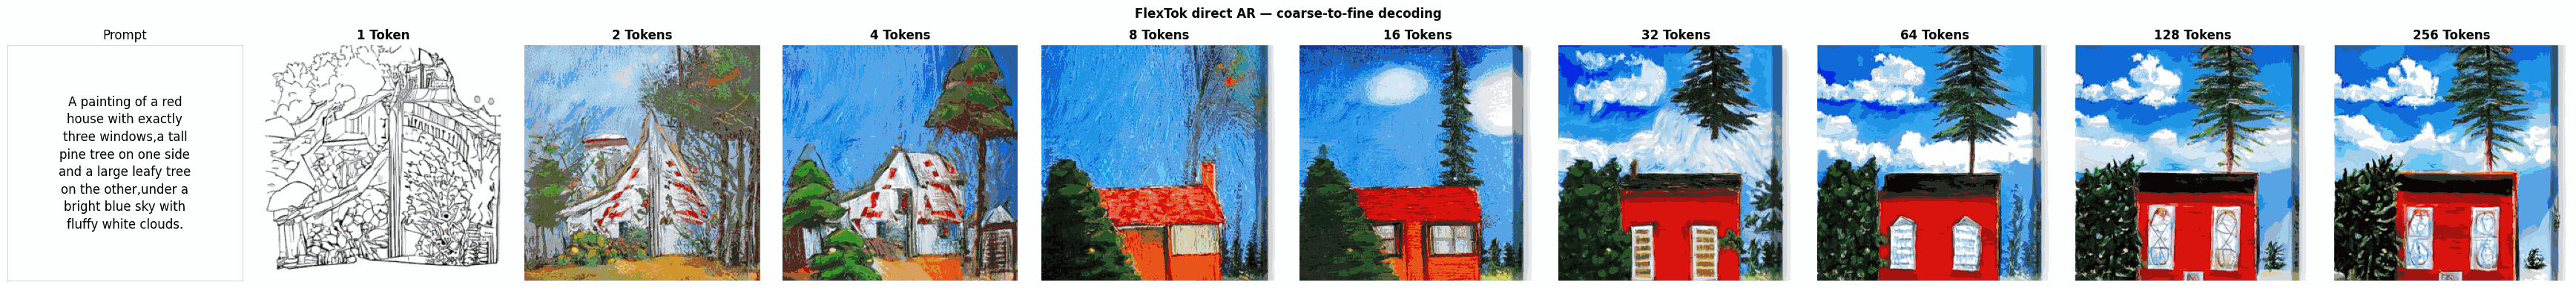

ImageReward score — FlexTok direct AR: 0.21


In [5]:
FLEX_TOKEN_COUNTS = [1, 2, 4, 8, 16, 32, 64, 128, 256] # The token numbers that flextok is explicitly trained on; You can also change to other values.

flex_model = flextok_prior.generator
flex_cfg = flextok_prior.cfg
gen_cfg = flex_cfg.generation

with torch.no_grad(), torch.cuda.amp.autocast(enabled=True, dtype=torch.float32):
    flex_all_tokens = flex_model.generate_ids(
        {"text": [PROMPT]},
        sample=gen_cfg.get("sample", True),
        temperature=gen_cfg.get("temperature", 1.0),
        top_k=gen_cfg.get("top_k", 0),
        top_p=gen_cfg.get("top_p", 0.0),
        cfg_factor=gen_cfg.get("cfg_factor", 3.0),
        generator=torch.Generator(device=device).manual_seed(0),
        num_keep_tokens=256,
    )
print(f"FlexTok tokens: {flex_all_tokens.shape}  first 8: {flex_all_tokens[0, :8].tolist()}")

flex_partial_images = []
for n_tok in FLEX_TOKEN_COUNTS:
    imgs = flextok_prior.decode_tokens(flex_all_tokens[:, :n_tok], timesteps=15, caption_idx=0)
    flex_partial_images.append(imgs[0])

show_images(
    flex_partial_images,
    titles=[f"{t} Token{'s' if t != 1 else ''}" for t in FLEX_TOKEN_COUNTS],
    main_title="FlexTok direct AR — coarse-to-fine decoding",
    prompt=PROMPT,
    ncols=len(FLEX_TOKEN_COUNTS)+1,
)

flex_score = verifier.score(flex_partial_images[-1], PROMPT)[0]
print(f"ImageReward score — FlexTok direct AR: {float(flex_score):.2f}")

## 3. Test-Time Search

Instead of accepting the first AR sample, we explore multiple candidate token sequences and keep the best one according to ImageReward.

| Algorithm | Description |
|-----------|-------------|
| **Best-of-N** | Generate N complete sequences independently; return the highest-scoring one |
| **Beam Search** | Maintain k beams; at each step branch each beam into M candidates, score partial images, keep top-k |
| **Lookahead** | Like beam search, but extend each candidate L more tokens before scoring for a more informative image |

Because FlexTok's partial sequences are semantically meaningful from token 1, the verifier gives reliable scores at every step — making early pruning effective.

### 3.1 Best-of-N

FlexTok best of N search score: 0.3987


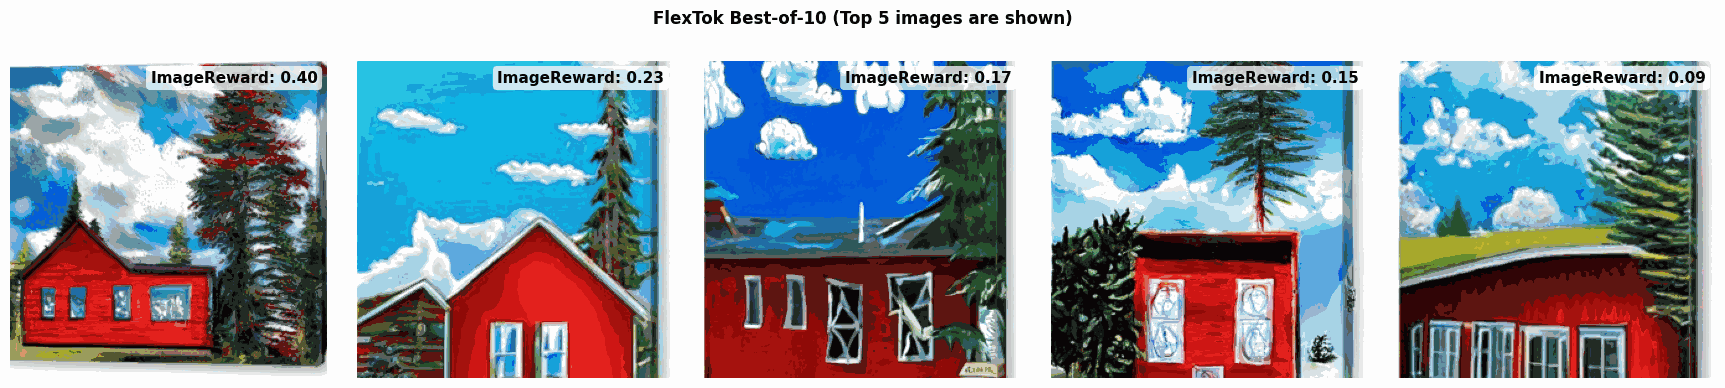

In [6]:
# Takes around 1 min to run on a H100.
N_SAMPLES = 10
TOP_K = 5

flex_bon_result = SearchAlgorithmFactory.create(
    "best_of_n", ar_prior=flextok_prior, verifier=verifier,
    config={"n_samples": N_SAMPLES, "decode_timesteps": 15},
).search(PROMPT, num_results=TOP_K, seed=FIXED_SEED)

print(f"FlexTok best of N search score: {flex_bon_result.scores[0]:.4f}")

show_images(
    flex_bon_result.images,
    overlay_labels=list(flex_bon_result.scores),
    overlay_prefix="ImageReward",
    ncols=TOP_K,
    main_title=f"FlexTok Best-of-{N_SAMPLES} (Top 5 images are shown)",
)

### 3.2 Beam Search

Maintains `beam_width=5` active sequences. At each step, each beam generates `candidates_per_beam=10` continuations; partial images are decoded and scored; only the top-5 survive. 

As a demo case, we set the `token_schedule` to [1,4,8,16,32],  which conducts beam search at the 1st, 4th, 8th, 16th, and 32nd tokens. The intermediate tokens are auto-completed using the original single next-token prediction. Feel free to experiment with other token schedules. 
In general, searching more token positions leads to better performance, but introduces additional computational cost. For efficiency, we typically do not search at every step, but instead advance linearly or geometrically across token positions to balance quality and runtime.

You can also increase the `beam_width` and `candidates_per_beam` to enlarge the search space, which usually leads to better results.

Step 5/5: 100%|██████████| 5/5 [01:15<00:00, 15.15s/step, score=0.473, tokens=32]


FlexTok beam search score: 0.4725


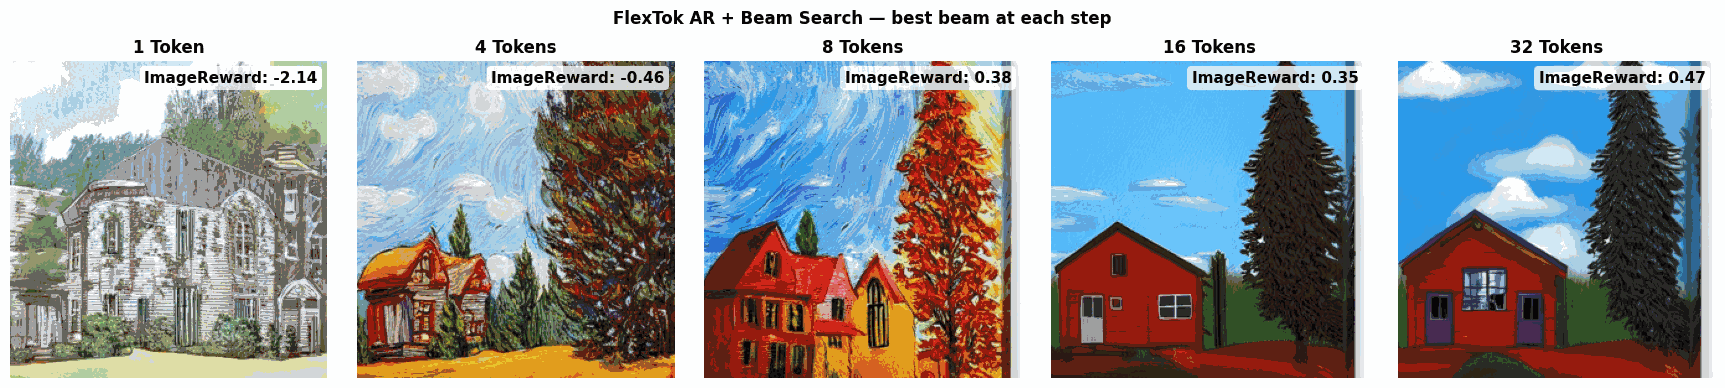

In [7]:
# Takes around 1 min to run on H100.
flextok_beam_result = SearchAlgorithmFactory.create(
    "beam",
    ar_prior=flextok_prior,
    verifier=verifier,
    config={
        "beam_width": 5,
        "candidates_per_beam": 10,
        "token_schedule": [1, 4, 8, 16, 32],
        "decode_timesteps": 15,
        "sample": True,
    }
).search(PROMPT, seed=FIXED_SEED)
print(f"FlexTok beam search score: {flextok_beam_result.scores[0]:.4f}")

show_images(
    flextok_beam_result.step_images,
    titles=list(str(s) + " Tokens" if s != 1 else "1 Token" for s in flextok_beam_result.metadata["step_schedule"]),
    overlay_labels=list(flextok_beam_result.step_scores),
    overlay_prefix="ImageReward",
    main_title="FlexTok AR + Beam Search — best beam at each step",
)

### 3.3 Lookahead Search

Like beam search, but each candidate is extended by `lookahead_number=4` extra tokens before scoring — giving the verifier a more complete image at each step. Sequences are also AR-completed to 256 tokens after search.

Step 5/5: 100%|██████████| 5/5 [00:47<00:00,  9.54s/step, score=0.781, tokens=32]


FlexTok lookahead search score: 0.7806


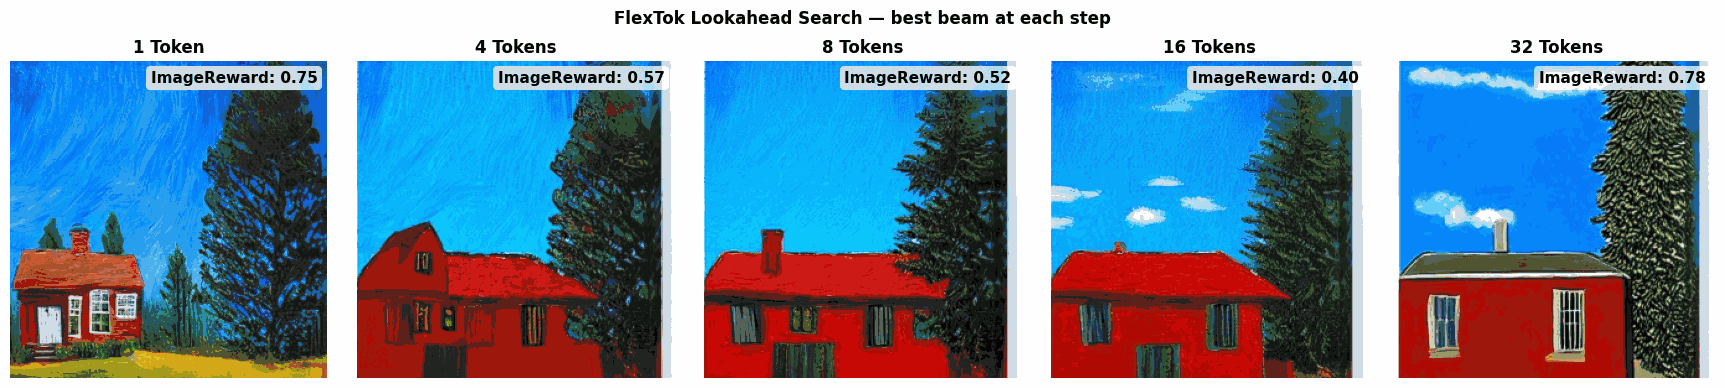

In [8]:
flex_la_result = SearchAlgorithmFactory.create(
    "lookahead", ar_prior=flextok_prior, verifier=verifier,
    config={
        "lookahead_number": 4,
        "beam_width": 5,
        "candidates_per_beam": 5,
        "token_schedule": [1, 4, 8, 16, 32],
        "decode_timesteps": 15,
    }
).search(PROMPT, seed=FIXED_SEED)
print(f"FlexTok lookahead search score: {flex_la_result.scores[0]:.4f}")

show_images(
    flex_la_result.step_images,
    titles=list(str(s) + " Tokens" if s != 1 else "1 Token" for s in flex_la_result.metadata["step_schedule"]),
    overlay_labels=list(flex_la_result.step_scores),
    overlay_prefix="ImageReward",
    main_title="FlexTok Lookahead Search — best beam at each step",
)

### 3.4 Summary: All Search Methods on FlexTok

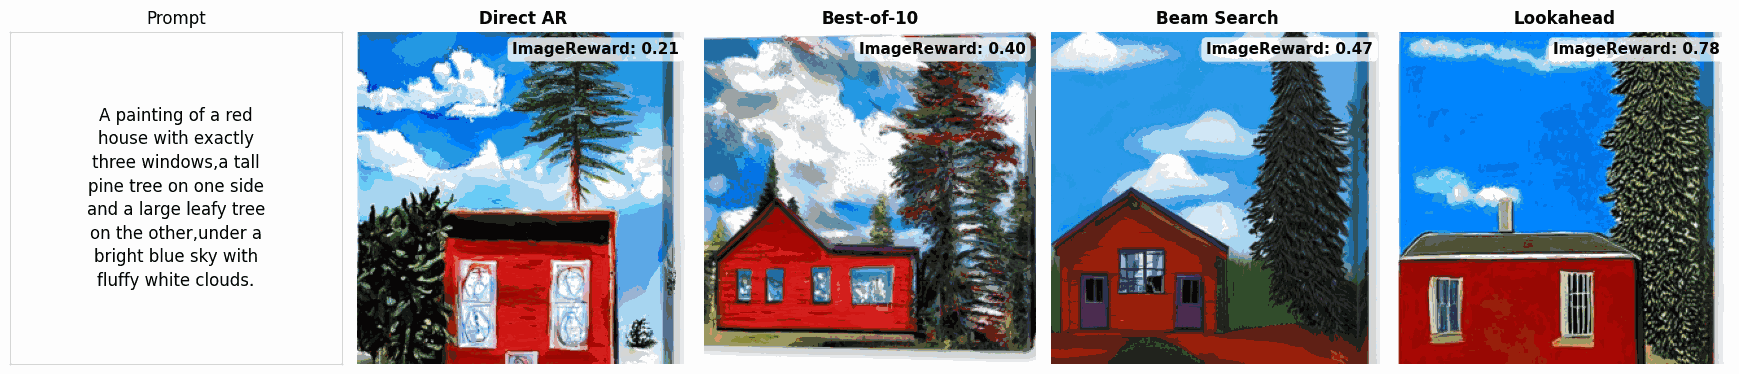

In [9]:
# ── FlexTok: Summary — one best image per method ─────────────────────────────
show_images(
    [
        flex_partial_images[-1],         # Direct AR (256 tokens)
        flex_bon_result.images[0],       # Best-of-N   (256 tokens, highest score)
        flextok_beam_result.images[0],   # Beam Search (256 tokens, AR-completed)
        flex_la_result.images[0],        # Lookahead   (256 tokens, AR-completed)
    ],
    titles=["Direct AR", f"Best-of-{N_SAMPLES}", "Beam Search", "Lookahead"],
    overlay_labels=[
        float(flex_score),
        float(flex_bon_result.scores[0]),
        float(flextok_beam_result.scores[0]),
        float(flex_la_result.scores[0]),
    ],
    overlay_prefix="ImageReward",
    prompt=PROMPT,
)

### 3.5 Comparison of Intermediate Steps Between Original AR and Test-Time Search

As shown below, at each step, test-time search attempts to find a better token sequence that more closely matches the final prediction. Since Lookahead has access to future tokens, its intermediate results are closer to the final outcome compared to standard step-by-step decoding.

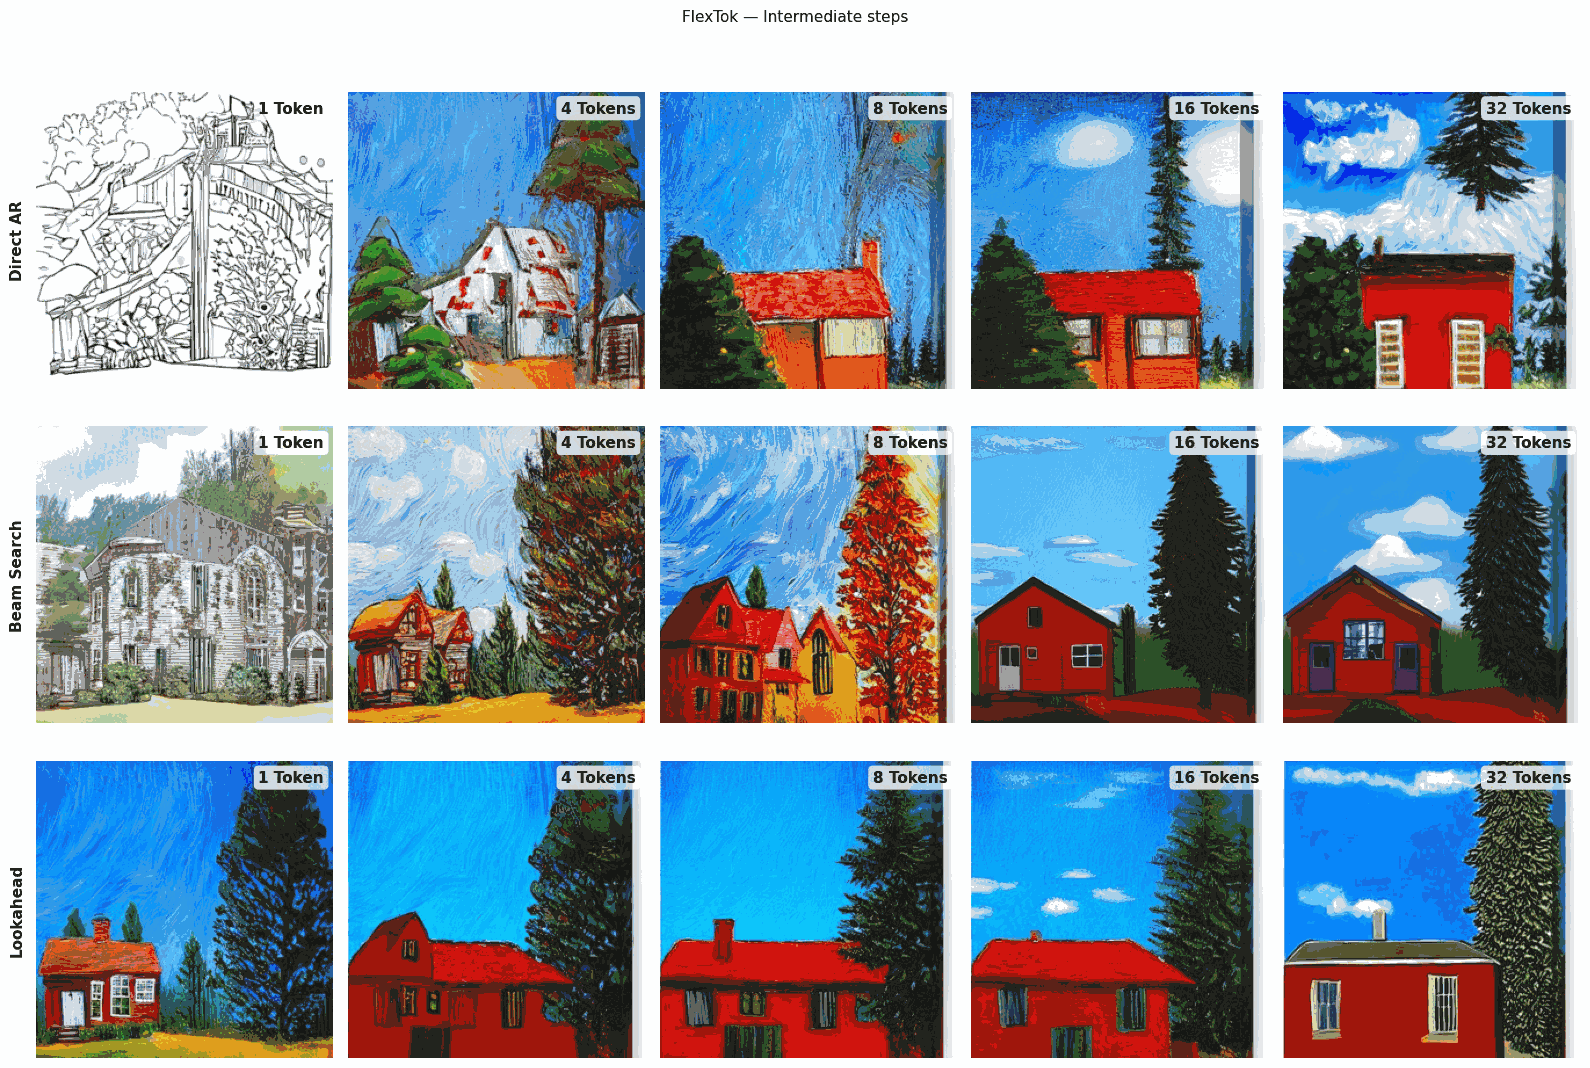

In [10]:
# ── FlexTok: Intermediate steps — rows = method, columns = search step ────────
FLEX_DISPLAY_COUNTS = [1, 4, 8, 16, 32]
flex_display_images = [flex_partial_images[FLEX_TOKEN_COUNTS.index(t)] for t in FLEX_DISPLAY_COUNTS]

show_rows(
    [
        ("Direct AR",   flex_display_images,             [f"{t} Token{'s' if t != 1 else ''}" for t in FLEX_DISPLAY_COUNTS]),
        ("Beam Search", flextok_beam_result.step_images, [f"{t} Token{'s' if t != 1 else ''}" for t in flextok_beam_result.metadata["step_schedule"]]),
        ("Lookahead",   flex_la_result.step_images,      [f"{t} Token{'s' if t != 1 else ''}" for t in flex_la_result.metadata["step_schedule"]]),
    ],
    title="FlexTok — Intermediate steps",
)

In [11]:
del flextok_prior
torch.cuda.empty_cache()

## 4. 2D grid tokens

Below, we demonstrate how to perform test-time search on an AR model that predicts tokens in a 2D raster-scan order. This structure differs from FlexTok’s coarse-to-fine ordering, where even a single token can capture global semantics.

Here, we load GridAR-3B, a controlled model with the same architecture and training compute as FlexAR-3B, and similar performance without test-time search.

In [12]:
gridtok_prior = ARPriorFactory.create("gridtok_ar_3b", device=device)
print("GridTok AR 3B loaded!")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 90.72it/s]


GridTok AR 3B loaded!


### 4.1 GridTok Progressive Decoding

GridTok tokens: torch.Size([1, 256])  first 8: [51716, 6593, 1075, 52315, 54369, 30414, 41132, 12832]


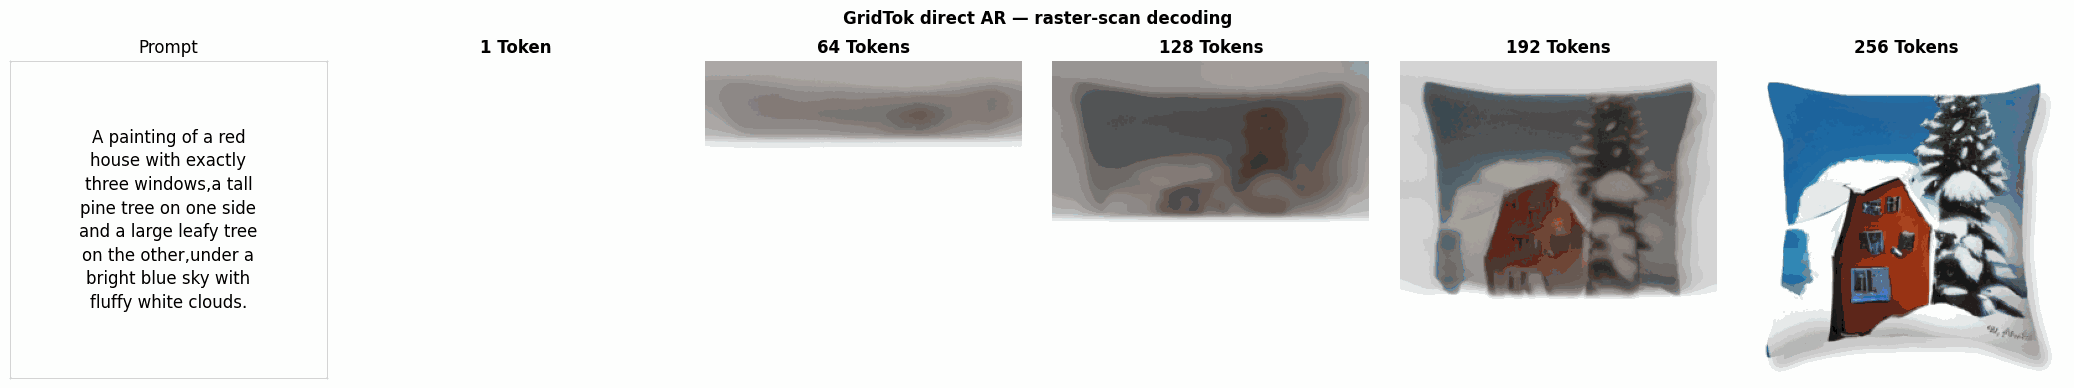

ImageReward score — GridTok direct AR: -0.69


In [13]:
# Each token covers a 16×16 patch in raster-scan order:
#   1 token = top-left patch only; 64 tokens = top quarter of the image.
GRID_TOKEN_COUNTS = [1, 64, 128, 192, 256]

grid_model = gridtok_prior.generator
grid_cfg = gridtok_prior.cfg
gen_cfg_g = grid_cfg.generation

with torch.no_grad(), torch.cuda.amp.autocast(enabled=True, dtype=torch.float32):
    grid_all_tokens = grid_model.generate_ids(
        {"text": [PROMPT]},
        sample=gen_cfg_g.get("sample", True),
        temperature=gen_cfg_g.get("temperature", 1.0),
        top_k=gen_cfg_g.get("top_k", 0),
        top_p=gen_cfg_g.get("top_p", 0.0),
        cfg_factor=gen_cfg_g.get("cfg_factor", 3.0),
        num_keep_tokens=256,
    )
print(f"GridTok tokens: {grid_all_tokens.shape}  first 8: {grid_all_tokens[0, :8].tolist()}")

grid_partial_images = []
for n_tok in GRID_TOKEN_COUNTS:
    imgs = gridtok_prior.decode_tokens(grid_all_tokens[:, :n_tok], timesteps=15, caption_idx=0)
    grid_partial_images.append(imgs[0])
    rows = n_tok // 16

show_images(
    grid_partial_images,
    titles=[f"{t} Token{'s' if t != 1 else ''}" for t in GRID_TOKEN_COUNTS],
    main_title="GridTok direct AR — raster-scan decoding",
    prompt=PROMPT,
    ncols=len(GRID_TOKEN_COUNTS) + 1,
)

grid_score = verifier.score(grid_partial_images[-1], PROMPT)[0]
print(f"ImageReward score — GridTok direct AR: {float(grid_score):.2f}")

### 4.3 Test-Time Search on GridTok

Same three algorithms as Section 3. Because partial GridTok images show only a spatial strip, verifier scores are less reliable at early steps — resulting in smaller gains from search compared to FlexTok.

  top-5 scores: ['0.289', '0.121', '-0.063', '-0.501', '-0.795']


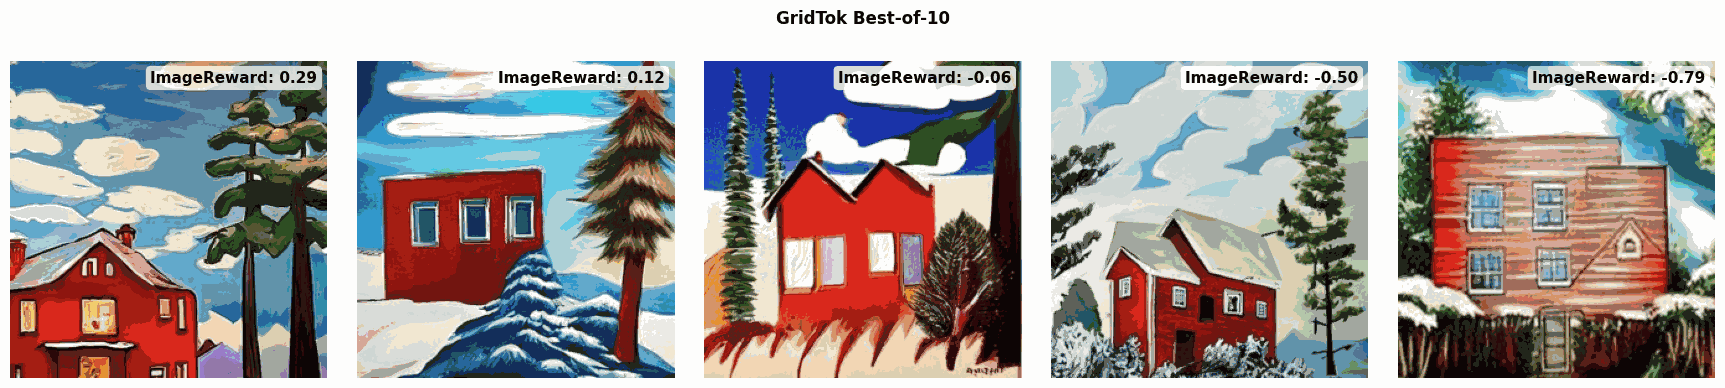

In [14]:
N_SAMPLES = 10
TOP_K = 5

grid_bon_result = SearchAlgorithmFactory.create(
    "best_of_n", ar_prior=gridtok_prior, verifier=verifier,
    config={"n_samples": N_SAMPLES, "decode_timesteps": 15},
).search(PROMPT, num_results=TOP_K, seed=FIXED_SEED)
print(f"  top-{TOP_K} scores: {[f'{s:.3f}' for s in grid_bon_result.scores.tolist()]}")

show_images(
    grid_bon_result.images,
    overlay_labels=list(grid_bon_result.scores),
    overlay_prefix="ImageReward",
    ncols=TOP_K,
    main_title=f"GridTok Best-of-{N_SAMPLES}",
)

Step 5/5: 100%|██████████| 5/5 [01:37<00:00, 19.42s/step, score=-1.277, tokens=256]


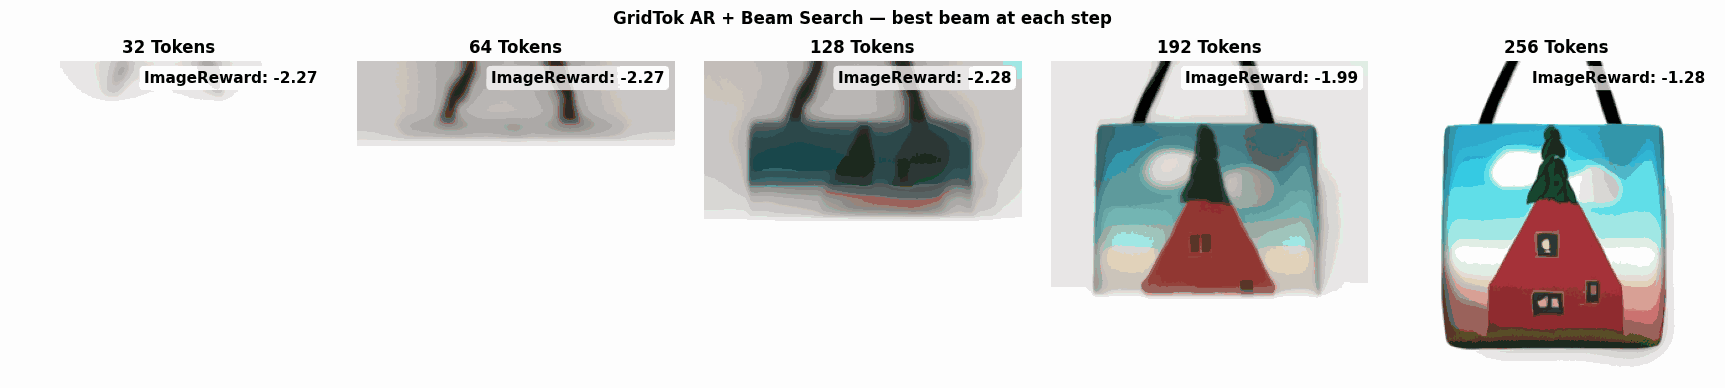

In [15]:
grid_beam_result = SearchAlgorithmFactory.create(
    "beam",
    ar_prior=gridtok_prior,
    verifier=verifier,
    config={
        "beam_width": 5,
        "candidates_per_beam": 10,
        "max_steps": 5,
        "token_schedule": [32, 64, 128, 192, 256],
        "decode_timesteps": 15,
    }
).search(PROMPT, seed=FIXED_SEED)

show_images(
    grid_beam_result.step_images,
    overlay_labels=list(grid_beam_result.step_scores),
    overlay_prefix="ImageReward",
    titles=list(str(s) + " Tokens" if s != 1 else "1 Token" for s in grid_beam_result.metadata["step_schedule"]),
    main_title="GridTok AR + Beam Search — best beam at each step",
)

Step 5/5: 100%|██████████| 5/5 [01:31<00:00, 18.36s/step, score=-0.728, tokens=256]


  GridTok Lookahead score: -0.7276


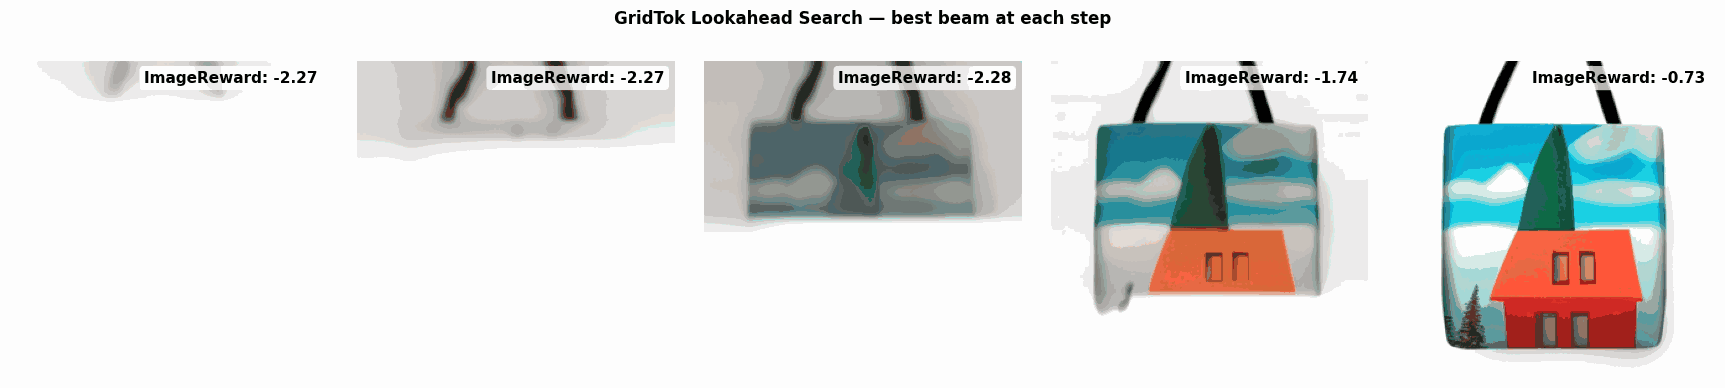

In [16]:
# Takes around 2mins to finish on a h100.
gridtok_la_result = SearchAlgorithmFactory.create(
    "lookahead", ar_prior=gridtok_prior, verifier=verifier,
    config={
        "lookahead_number": 4, # You can change this to -1 to do full lookahead till 256 tokens.   
        "beam_width": 5,
        "candidates_per_beam": 5, # To avoid OOM.
        "max_steps": 5,
        "token_schedule": [32, 64, 128, 192, 256],
        "decode_timesteps": 15,
    },
).search(PROMPT, seed=FIXED_SEED)
print(f"  GridTok Lookahead score: {gridtok_la_result.scores[0]:.4f}")

show_images(
    gridtok_la_result.step_images,
    overlay_labels=list(gridtok_la_result.step_scores),
    overlay_prefix="ImageReward",
    main_title="GridTok Lookahead Search — best beam at each step",
)

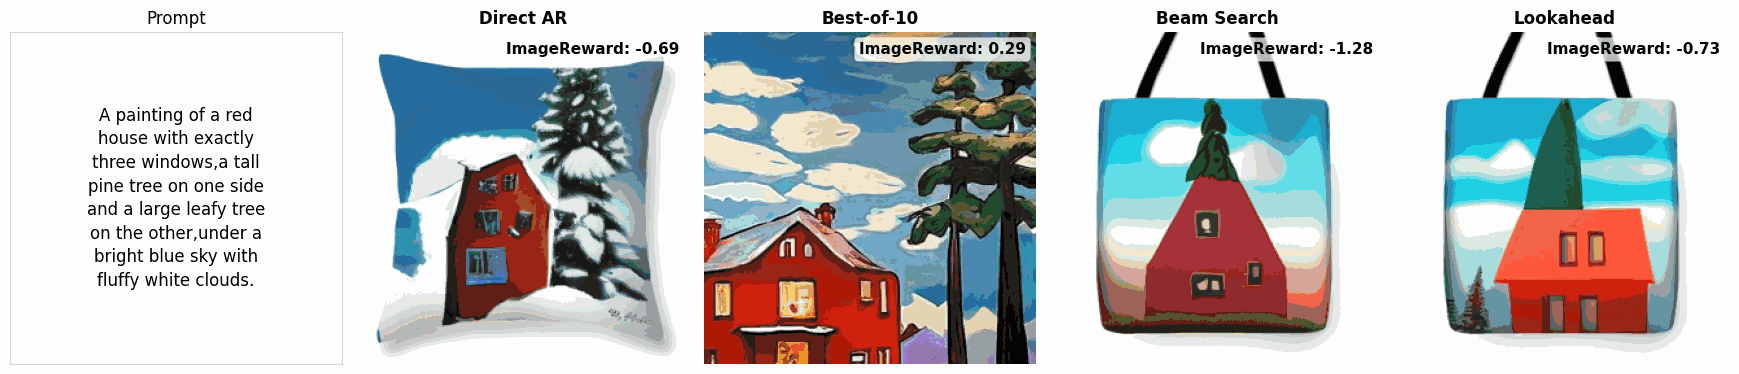

In [17]:
# ── GridTok Summary — one best image per method ───────────────────────────────
show_images(
    [
        grid_partial_images[-1],       # Direct AR (256 tokens)
        grid_bon_result.images[0],     # Best-of-N   (highest score)
        grid_beam_result.images[0],    # Beam Search (best result)
        gridtok_la_result.images[0],   # Lookahead   (best result)
    ],
    titles=["Direct AR", f"Best-of-{N_SAMPLES}", "Beam Search", "Lookahead"],
    overlay_labels=[
        float(grid_score),
        float(grid_bon_result.scores[0]),
        float(grid_beam_result.scores[0]),
        float(gridtok_la_result.scores[0]),
    ],
    overlay_prefix="ImageReward",
    prompt=PROMPT,
)

## Takeaways

- You can initialize an AR model, a verifier, and a search algorithm to perform test-time search.
- Test-time search guided by a verifier can generally improve generation quality, although the effectiveness depends on both the search algorithm and the verifier. In Notebook 03, we explore additional verifiers, and in Notebook 04, we examine other AR models. In Notebook 02, we take a deeper look at the FlexTok token structure and show that generation is possible even without an AR model.
- Token structure affects test-time search. FlexTok, with a coarse-to-fine structure, is more verifiable during the generation process and has the potential to benefit more from test-time search than a 2D grid token-based AR model.